In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# **Step1: Importing Libraries**

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV

from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score,accuracy_score 


# **Step2: Data Loading**

In [3]:
train_data=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_data=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

# Shape of Data

In [4]:
print(train_data.shape)
print(test_data.shape)

(198000, 15)
(102000, 14)


In [5]:
train_data.head(3)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2


# **Step3: Exploratory Data Analysis** 

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
train_data.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


 **Checking null values**

In [8]:
train_data.isna().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [9]:
test_data.isna().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

**Checking Distribution of Label column**

In [10]:
train_data['label'].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

# **step4: Visualisations**

Text(0.5, 1.0, 'Distribution of Target Labels')

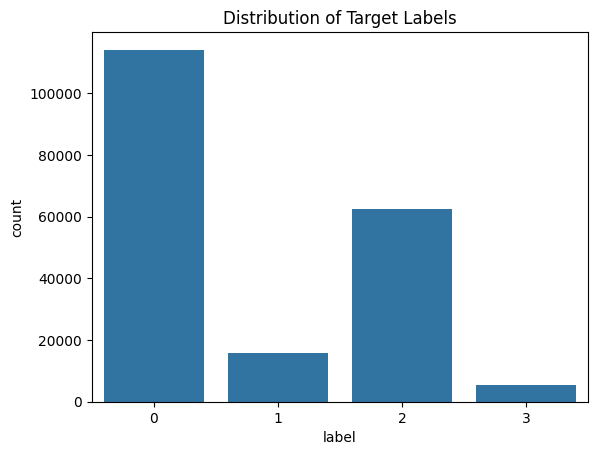

In [11]:
sns.countplot(x='label', data=train_data)
plt.title("Distribution of Target Labels")

Note: The dataset is imbalanced

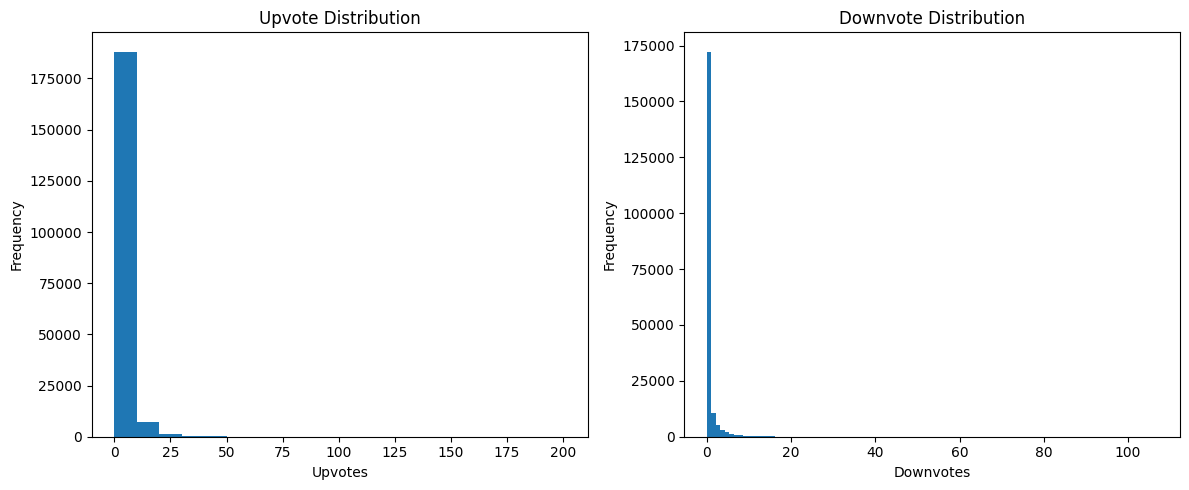

In [12]:
plt.figure(figsize=(12,5))

#Upvote histogram
plt.subplot(1,2,1)
plt.hist(train_data['upvote'], bins=20)
plt.title("Upvote Distribution")
plt.xlabel("Upvotes")
plt.ylabel("Frequency")

# Downvote histogram
plt.subplot(1,2,2)
plt.hist(train_data['downvote'], bins=100)
plt.title("Downvote Distribution")
plt.xlabel("Downvotes")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Note: The distribution of upvotes and downvotes is highly right-skewed indicates presence of outliers

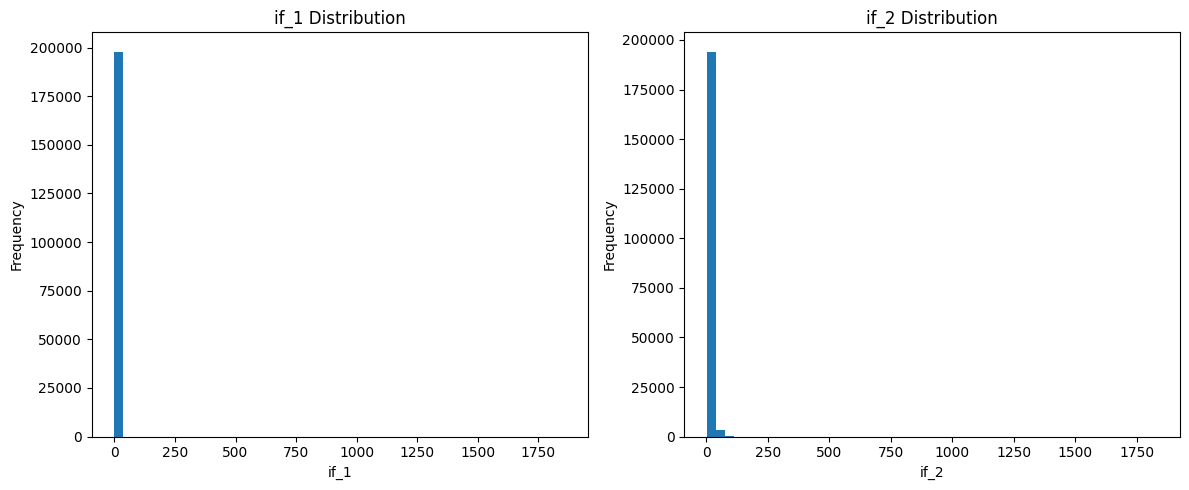

In [13]:
plt.figure(figsize=(12,5))

#if_1 histogram
plt.subplot(1,2,1)
plt.hist(train_data['if_1'], bins=50)
plt.title("if_1 Distribution")
plt.xlabel("if_1")
plt.ylabel("Frequency")

# if_2 histogram
plt.subplot(1,2,2)
plt.hist(train_data['if_2'], bins=50)
plt.title("if_2 Distribution")
plt.xlabel("if_2")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# **Step5: Data Preprocessing and Feature Engeneering**

In [14]:
def clean_data(data):
    # Drop columns with high missing values
    data = data.drop(columns=['race','religion','gender'], errors="ignore")
    # Fill missing comments
    data["comment"] = data["comment"].fillna("")
    # Remove duplicate rows
    data.drop_duplicates(inplace=True)

    #Convert boolean to integer (0/1)
    data['disability'] = data['disability'].astype(int)
    
     #Convert to datetime and extract timebased features
    data['created_date'] = pd.to_datetime(data['created_date'])

    data['year'] = data['created_date'].dt.year
    data['month'] = data['created_date'].dt.month
    data['day'] = data['created_date'].dt.day
    data['dayofweek'] = data['created_date'].dt.dayofweek
    
     #Number of characters in comment
    data['noof_char'] = data['comment'].str.len()

    #log transformation for skewness
    data["upvote"] = np.log1p(data["upvote"])
    data["downvote"] = np.log1p(data["downvote"])
    data["if_1"] = np.log1p(data["if_1"])
    data["if_2"] = np.log1p(data["if_2"])
    
    #Difference between upvotes and downvotes
    data["vote_score"] = data["upvote"] - data["downvote"]
    #Total engagement
    data["total_votes"] = data["upvote"] + data["downvote"]

    return data

In [15]:
train_data = clean_data(train_data)
test_data = clean_data(test_data)


In [16]:
text_col = "comment"

In [17]:
numeric_cols = [
    'emoticon_1','emoticon_2','emoticon_3',
    'vote_score','if_1','if_2','disability','total_votes',
    'noof_char','year','month','day','dayofweek'
]
#Removed:upvote,downvote,postid,Race,religion,gender,created date

**Feature Matrix Correlation**

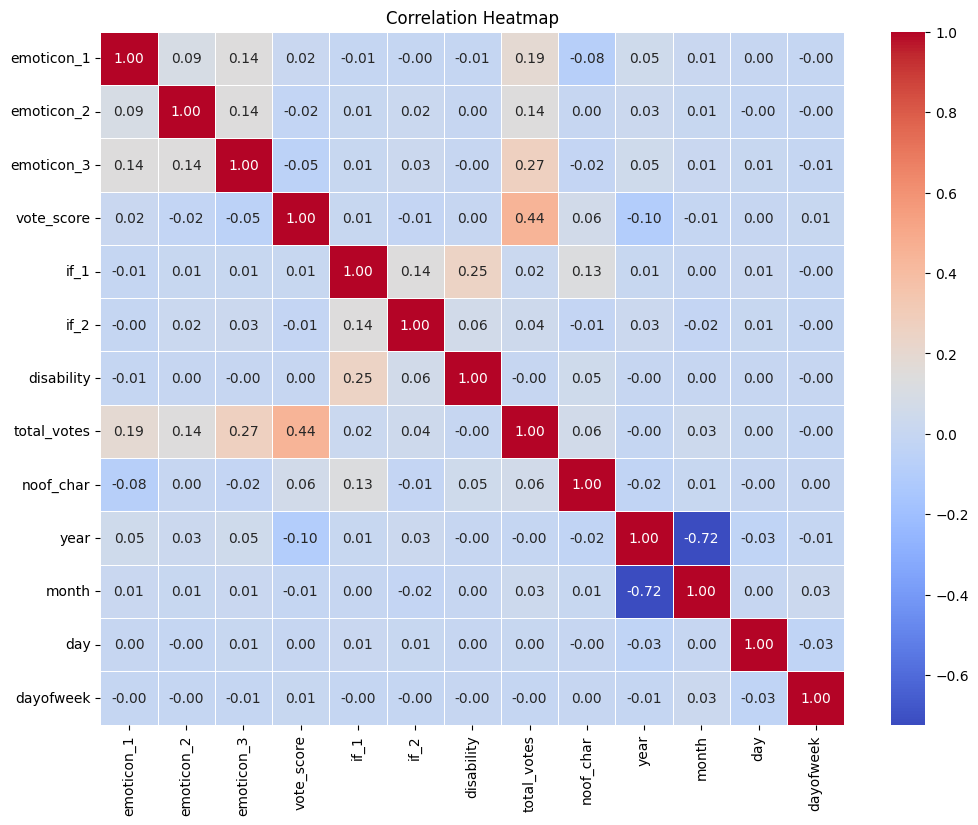

In [18]:
plt.figure(figsize=(12,9))
corr =train_data[numeric_cols] .corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Vote Score Distribution accross Target labels**

<Axes: xlabel='label', ylabel='vote_score'>

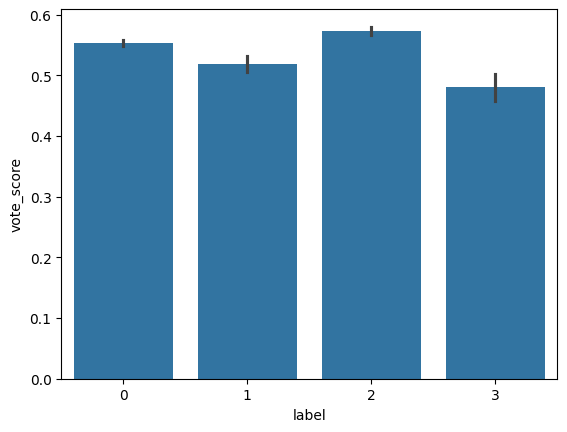

In [19]:
sns.barplot(x='label', y='vote_score', data=train_data)

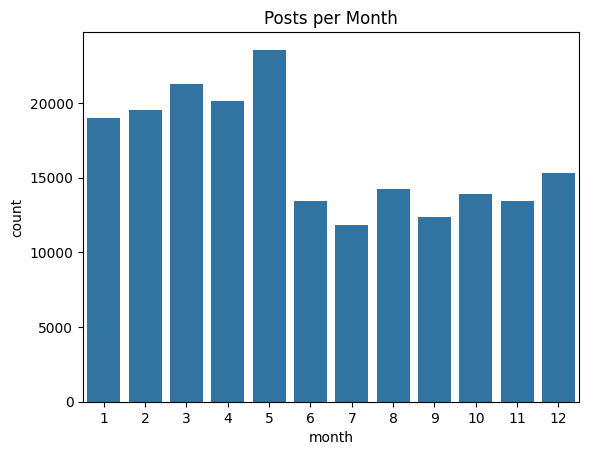

In [20]:
sns.countplot(x='month',data=train_data)
plt.title("Posts per Month")
plt.show()

# **Step6: Split the dataset**

In [21]:
X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]

X_train, X_test, y_train, y_test= train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# **Step7: Build model**

**Model1: Logistic Regression**

In [22]:
#preprocessing pipeline
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(
             max_features=80000,
             stop_words="english",
             ngram_range=(1,1),
             max_df=0.8
         ),
         text_col),

        ("num",
         StandardScaler(),
         numeric_cols)
    ]
)

In [23]:
#Logistic Regression Model
lr_model= LogisticRegression(C=0.5,
                             max_iter=2000,
                             class_weight={0:1,1:2,2:1,3:4})

In [24]:

lr_pipeline = Pipeline([
        ("preprocess", lr_preprocessor),   
        ("model", lr_model)
    ])
    
lr_pipeline.fit(X_train, y_train)
    


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.8,
                                                                  max_features=80000,
                                                                  stop_words='english'),
                                                  'comment'),
                                                 ('num', StandardScaler(),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'vote_score',
                                                   'if_1', 'if_2', 'disability',
                                                   'total_votes', 'noof_char',
                                                   'year', 'month', 'day',
                                                   'dayofweek'])])),
                ('model',
                 LogisticRegression(C=0.5,
                                    class_weight={0: 1, 1: 2, 2: 1, 3: 4},
                                    max_iter=2000))])

# **Step8: Evaluate Model**

In [25]:
y_pred = lr_pipeline.predict(X_test)
    
acc = accuracy_score(y_test, y_pred)

#Accuracy   
print(f"Accuracy: {acc:.4f}")

#Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.9069
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.74      0.80      0.77      3183
           2       0.86      0.89      0.88     12488
           3       0.62      0.65      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.80      0.82      0.81     39600
weighted avg       0.91      0.91      0.91     39600



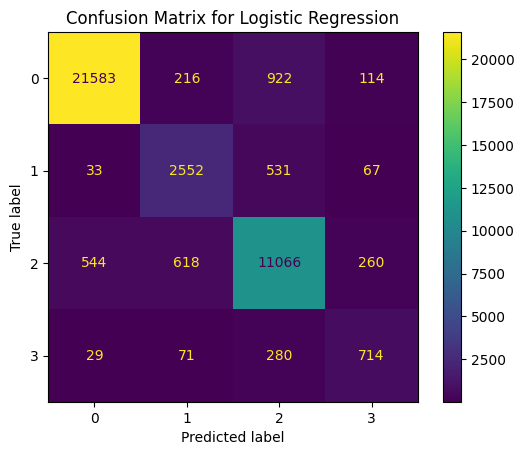

In [26]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = [
    # L2 with lbfgs (best for TF-IDF)
    {
        'model__C': [0.1, 0.5, 1, 2, 5, 10],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs']
    },
    
    # L1 with liblinear (feature selection effect)
    {
        'model__C': [0.1, 0.5, 1, 2],
        'model__penalty': ['l1'],
        'model__solver': ['liblinear']
    }
]

In [28]:
random_search = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=param_dist,
    n_iter=6,                  
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('text',
                                                                               TfidfVectorizer(max_df=0.8,
                                                                                               max_features=80000,
                                                                                               stop_words='english'),
                                                                               'comment'),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               ['emoticon_1',
                                                                                'emoticon_2',
                                                                                'emoticon_3',
                                                                                'vote_score',
                                                                                'if_1',
                                                                                'if_2',
                                                                                'disability',
                                                                                'total_votes',
                                                                                'noof_char',
                                                                                'year',
                                                                                'month',
                                                                                'day',
                                                                                'dayofweek'])])),
                                             ('model',
                                              LogisticRegression(C=0.5,
                                                                 class_weight={0: 1,
                                                                               1: 2,
                                                                               2: 1,
                                                                               3: 4},
                                                                 max_iter=2000))]),
                   n_iter=6, n_jobs=-1,
                   param_distributions=[{'model__C': [0.1, 0.5, 1, 2, 5, 10],
                                         'model__penalty': ['l2'],
                                         'model__solver': ['lbfgs']},
                                        {'model__C': [0.1, 0.5, 1, 2],
                                         'model__penalty': ['l1'],
                                         'model__solver': ['liblinear']}],
                   random_state=42, scoring='f1_weighted')

In [29]:
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 1}


In [30]:
best_model = random_search.best_estimator_

In [31]:
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9117171717171717
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.77      0.78      0.77      3183
           2       0.85      0.92      0.89     12488
           3       0.65      0.59      0.62      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.81      0.81     39600
weighted avg       0.91      0.91      0.91     39600



**Model2 : SVM**

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(
             max_features=15000,
             stop_words="english",
             ngram_range=(1,2),
             max_df=0.8
         ),
         text_col),

        ("num",
         StandardScaler(),
         numeric_cols)
    ]
)

svm_model = LinearSVC(
    C=1.0,              
    class_weight={0:1,1:2,2:1,3:4},  
    max_iter=5000,
    random_state=42
)

In [33]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", svm_model)
])

svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.8,
                                                                  max_features=15000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'comment'),
                                                 ('num', StandardScaler(),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'vote_score',
                                                   'if_1', 'if_2', 'disability',
                                                   'total_votes', 'noof_char',
                                                   'year', 'month', 'day',
                                                   'dayofweek'])])),
                ('model',
                 LinearSVC(class_weight={0: 1, 1: 2, 2: 1, 3: 4}, max_iter=5000,
                           random_state=42))])

In [34]:
preds = svm_pipeline.predict(X_test)
f1_score = f1_score(y_test, preds,average="macro")

print("F1 score:",f1_score)
print(metrics.classification_report(y_test, preds))

F1 score: 0.7878040383528574
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22835
           1       0.74      0.75      0.74      3183
           2       0.85      0.89      0.87     12488
           3       0.60      0.58      0.59      1094

    accuracy                           0.90     39600
   macro avg       0.79      0.79      0.79     39600
weighted avg       0.90      0.90      0.90     39600



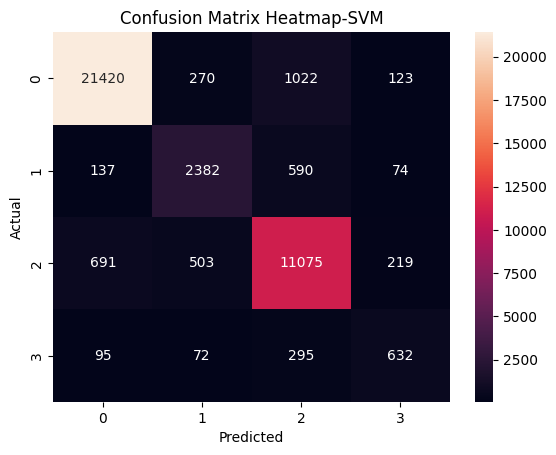

In [35]:
cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap-SVM")
plt.show()

**Model3: XGBoost**

In [36]:
!pip install xgboost

In [37]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softmax',  
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

xgb_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model', xgb_model)
])

In [38]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.8,
                                                                  max_features=15000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'comment'),
                                                 ('num', StandardScaler(),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'vote_score',
                                                   'if_1', 'if_2', 'disability',
                                                   'total_votes', 'noof_char',
                                                   'year', 'month', 'day',
                                                   'dayofweek'])])),
                ('model',
                 XGBC...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None, num_class=4, ...))])

In [39]:

preds = xgb_pipeline.predict(X_test)

In [41]:
from sklearn.metrics import f1_score
from sklearn import metrics

In [42]:
score = f1_score(y_test, preds,average="macro")

print("F1 score:", score)
print(metrics.classification_report(y_test, preds))

F1 score: 0.7756140653118855
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.79      0.71      0.75      3183
           2       0.83      0.93      0.87     12488
           3       0.74      0.40      0.52      1094

    accuracy                           0.91     39600
   macro avg       0.83      0.75      0.78     39600
weighted avg       0.91      0.91      0.90     39600



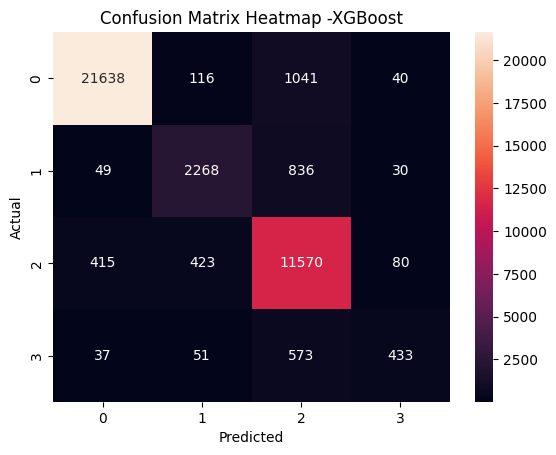

In [43]:
cm = confusion_matrix(y_test,preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap -XGBoost")
plt.show()

In [44]:
X_test=test_data
pred_labels=best_model.predict(X_test)

submission=pd.DataFrame({"ID":range(1,pred_labels.shape[0]+1),"label":pred_labels})

submission.to_csv("submission.csv",index=False)

In [50]:
from sklearn.datasets import load_iris
data=load_iris()


In [54]:
(X,y)=data.data,data.target


In [58]:
from sklearn import tree

from sklearn.tree import DecisionTreeClassifier

dt=tree.DecisionTreeClassifier()

dt.fit(X,y)



DecisionTreeClassifier()

[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, '

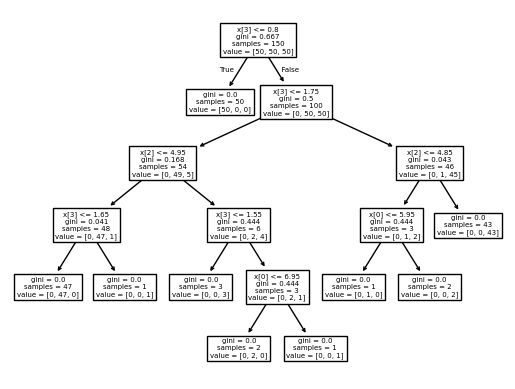

In [60]:
tree.plot_tree(dt)

In [ ]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(X_train,y_train)

In [ ]:
'''X_test=test_data
y_pred=model.predict(X_test)

submission=pd.DataFrame({"ID":range(1,X_test.shape[0]+1),"label":y_pred})

submission.to_csv("submission.csv",index=False)'''

In [ ]:
# submission=pd.DataFrame({"ID":range(1,test_data.shape[0]+1),"label":pred_labels})

# submission.to_csv("submission.csv",index=False)